## Plane Timoshenko beam structure

This example demonstrates how a **2D Timoshenko beam model** can be formulated directly in LowLevelFEM using its weak-form DSL.

Instead of relying on a dedicated beam element implementation, the beam kinematics are constructed from two independent fields:

* a 2D displacement field $\mathbf{u}=(u_x,u_y)$,
* a scalar cross-section rotation field $\varphi$.

The geometry itself may consist of arbitrarily oriented straight beam segments. Local tangent and normal directions are obtained directly from the mesh geometry, so arbitrarily oriented members can be treated by the same formulation without introducing member-specific local coordinate systems.


In [1]:
using LowLevelFEM

In [17]:
openGeometry("beam.geo")
openPreProcessor() # elements per rod and polynomial order can be changed here

mat = Material("beam")
U = Field([mat], type=:VectorField, dim=2, fieldName=:u, rhsName=:f)
Φ = Field([mat], type=:ScalarField, dim=2, fieldName=:φ, rhsName=:m, reducedOrder=true);

A reduced interpolation order is used for the rotation field. This avoids an overly stiff representation of the shear term and helps suppress shear locking in slender beams.

### Generalized beam strains

For a beam with unit tangent vector $\mathbf{t}$ and in-plane normal vector $\mathbf{n}$, the generalized Timoshenko strains are

$$
\varepsilon = \mathbf{t}^{\mathrm T}(\nabla\mathbf{u})\mathbf{t},
$$

$$
\gamma = \mathbf{n}^{\mathrm T}(\nabla\mathbf{u})\mathbf{t}-\varphi,
$$

$$
\kappa_b = \nabla\varphi\cdot\mathbf{t},
$$

where

* $\varepsilon$ is the axial strain,
* $\gamma$ is the transverse shear strain,
* $\kappa_b$ is the bending curvature.

These relations can be represented by the differential operators

$$
\boldsymbol{\varepsilon}_b
=
\mathbf B_u\,\mathbf u
+
\mathbf B_\varphi\,\varphi,
$$

with the corresponding operators assembled directly from the tangent and normal components of the beam.

The constitutive matrix is

$$
\mathbf D =
\begin{bmatrix}
EA & 0 & 0\\
0 & \kappa_s GA & 0\\
0 & 0 & EI_z
\end{bmatrix},
$$

where $A$ is the cross-sectional area, $I_z$ is the second moment of area, and $\kappa_s$ is the shear correction factor.


In [3]:
t = tangentVector(U, "beam")
tx, ty, tz = t[1], t[2], t[3]

nx = -ty
ny = tx
nz = 0;

In [4]:
# ------------------------------------------------------------------
# Generalized Timoshenko beam strain
#
# ε = tᵀ ∇u t
# γ = nᵀ ∇u t - φ
# κ = ∇φ ⋅ t
# ------------------------------------------------------------------

Au = [
    tx*tx tx*ty tx*ty ty*ty
    nx*tx nx*ty ny*tx ny*ty
    0 0 0 0]

Aφ = [
    0 0
    0 0
    tx ty]

Gφ = [0; -1; 0;;]

Bu = Au ⋅ Grad(U)

Bφ = Aφ ⋅ Grad(Φ) + Gφ ⋅ Φ;

### Weak form

The stiffness matrix of the coupled displacement–rotation system follows directly from the bilinear form

$$
K
=
\int_{\Gamma}
\mathbf B^{\mathrm T}
\mathbf D
\mathbf B
\,\mathrm ds,
\qquad
\mathbf B=\mathbf B_u+\mathbf B_\varphi .
$$

In LowLevelFEM this expression can be written almost literally:

```julia
B = Bu + Bφ
K = ∫(B' ⋅ D ⋅ B, Γ="beam")
```

This is the main point of the example: the beam formulation is defined at the operator and weak-form level, while element integration and global sparse assembly are handled automatically by LowLevelFEM.

In [5]:
b = 30
h = 5
E = mat.E
G = mat.μ
Iz = b * h^3 / 12
κ = 4 / 5
A = b * h;

In [6]:
D = [
    E*A 0 0
    0 κ*G*A 0
    0 0 E*Iz]

3×3 Matrix{Float64}:
 3.0e7  0.0        0.0
 0.0    9.23077e6  0.0
 0.0    0.0        6.25e7

In [7]:
B = Bu + Bφ
K = ∫(B' ⋅ D ⋅ B, Γ="beam");


### Boundary conditions and loading

The structure is clamped at point $A$, where both displacement components and the cross-section rotation are prescribed.

Three different external actions are applied:

- a horizontal concentrated force at point $E$,
- a uniformly distributed vertical load along segment $CD$,
- a concentrated moment at point $B$.

The displacement and rotation fields are solved simultaneously as a coupled system.

In [8]:
supp_u = BoundaryCondition("A", field=U, ux=0, uy=0)
supp_φ = BoundaryCondition("A", field=Φ, φ=0);

In [9]:
loadF = LoadCondition("E", fx=100)
loadf = LoadCondition("CD", fy=-1)
loadM = LoadCondition("B", m=4000)

fu = loadVector(U, [loadF, loadf])
fφ = loadVector(Φ, [loadM])

F = SystemVector([fu, fφ]);

The same load vector can also be assembled directly from linear forms:

In [10]:
fu = ∫(U ⋅ [100, 0], Γ="E")
fu2 = ∫(U ⋅ [0.0, -1], Γ="CD")
fφ = ∫(Φ ⋅ 4000, Γ="B")

F = SystemVector([fu + fu2, fφ]);

In [11]:
u, φ = solveField(K, F, support=[supp_u, supp_φ]);

In [12]:
showDoFResults(fu + fu2, name="force")
showDoFResults(u, name="u", factor=20, visible=true);

### Deformed shape

The figure below shows the undeformed and deformed beam structure together with the applied loads.

The displacement field is magnified for visualization. The deformation illustrates the combined effect of axial deformation, transverse shear and bending captured by the Timoshenko formulation.

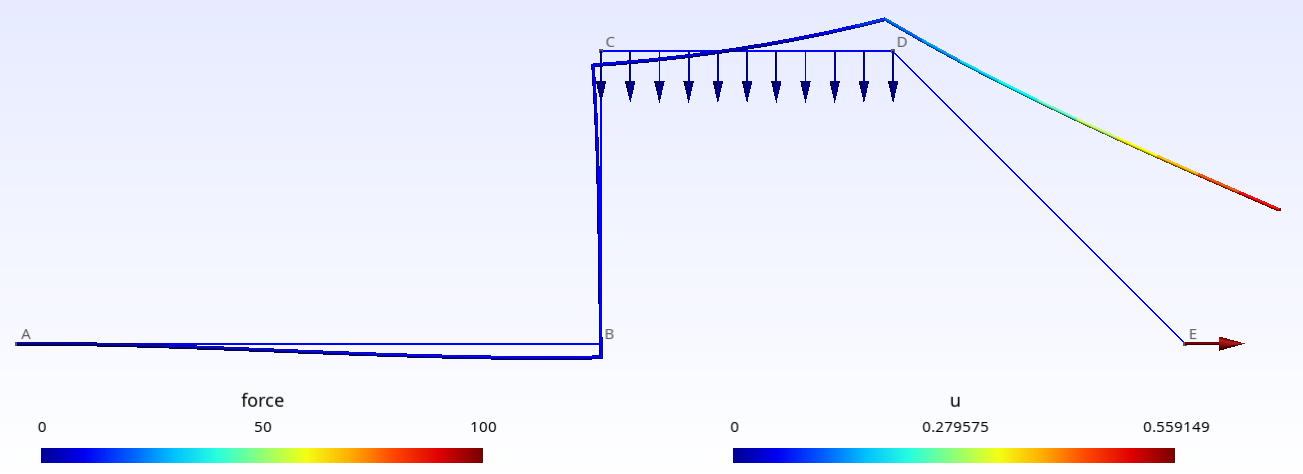

### Internal forces

After solving the displacement and rotation fields, the generalized strains are evaluated directly from the numerical solution:

$$
\varepsilon
=
\mathbf t^{\mathrm T}(\nabla\mathbf u)\mathbf t,
\qquad
\gamma
=
\mathbf n^{\mathrm T}(\nabla\mathbf u)\mathbf t-\varphi,
\qquad
\kappa_b
=
\nabla\varphi\cdot\mathbf t.
$$

The corresponding section resultants are then obtained as

$$
N = EA\,\varepsilon,
$$

$$
T = \kappa_s GA\,\gamma,
$$

$$
M = EI_z\,\kappa_b.
$$

The diagrams below show the axial force $N$, shear force $T$, and bending moment $M$ along the complete beam path.

The jumps in the axial and shear force diagrams correspond to concentrated loads or changes in loading, while the slope of the bending-moment diagram reflects the local shear force.

In [13]:
n = VectorField([nx, ny, 0]);

In [14]:
u = expandTo3D(u)
φ = nodesToElements(φ)

g = ∇(u)

ε = t ⋅ (g * t)
γ = n ⋅ (g * t) - φ

κb = ∇(φ) ⋅ t

N = E * A * ε
T = κ * G * A * γ
Mh = E * Iz * κb;

In [15]:
plotOnBeam("beam", N, name="N graph")
plotOnBeam("beam", T, name="T graph")
plotOnBeam("beam", Mh, name="Mh graph")

4

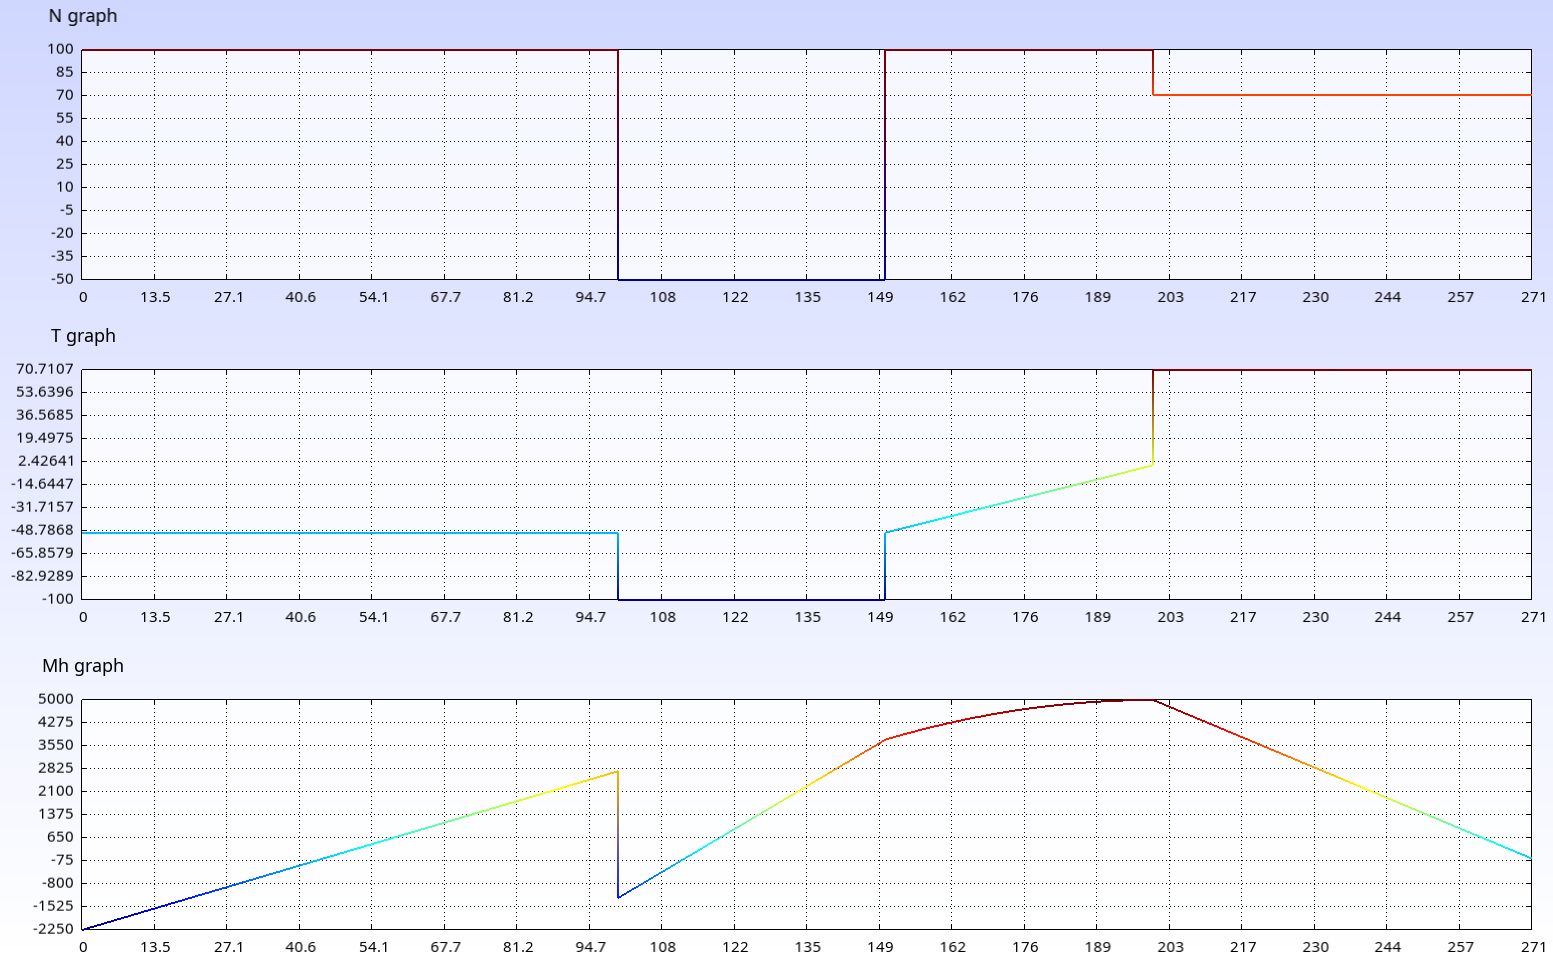

In [16]:
openPostProcessor()

### Takeaway

No dedicated beam element is implemented or called in this example.

The Timoshenko beam equations are built directly from

- field variables,
- geometric tangent and normal vectors,
- differential operators,
- constitutive relations,
- and the weak form.

The beam formulation is assembled from the same field, operator, integration, and sparse assembly machinery used by LowLevelFEM for continuum and multiphysics problems.